# **Data**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/diamonds.csv")



In [3]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
df["cut"].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [5]:
df["color"].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [6]:
df["clarity"].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

# **Data Preprocessing**

In [7]:
#step1

In [8]:
df.isnull().sum()


,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [9]:
# Step 2: Replace 0 with NaN

In [10]:
import numpy as np

In [11]:
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

In [12]:
# Fill NaN with median


In [13]:
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].fillna(df[['x', 'y', 'z']].median())

In [14]:
print(df[['x', 'y', 'z']].describe())

                  x             y             z
count  53940.000000  53940.000000  53940.000000
mean       5.732003      5.735267      3.540043
std        1.119587      1.140265      0.702400
min        3.730000      3.680000      1.070000
25%        4.710000      4.720000      2.910000
50%        5.700000      5.710000      3.530000
75%        6.540000      6.540000      4.040000
max       10.740000     58.900000     31.800000


# **Outliers Handling**

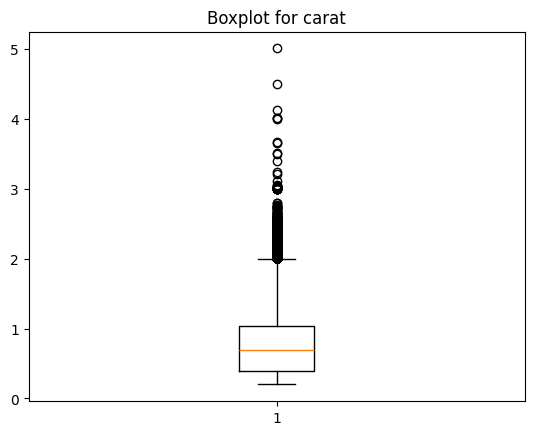

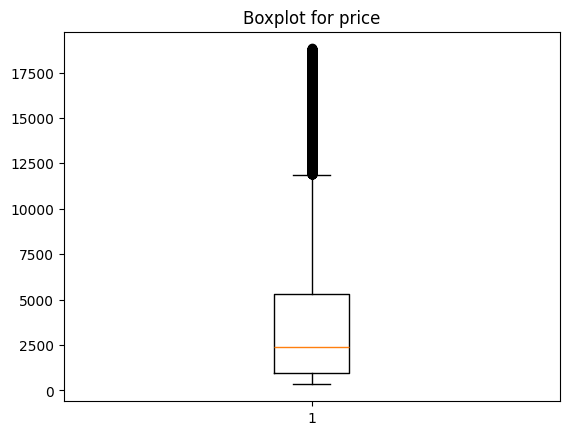

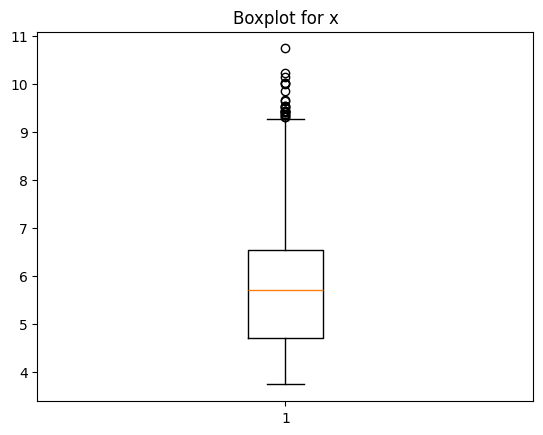

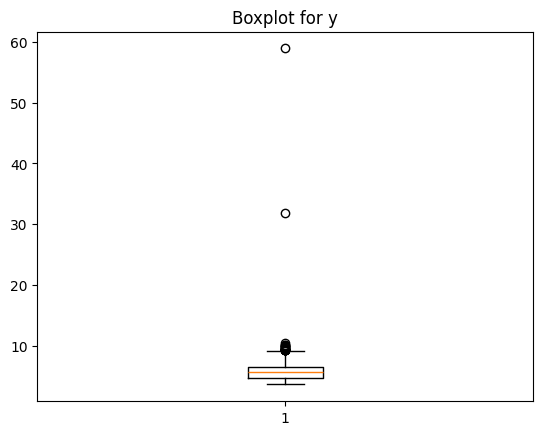

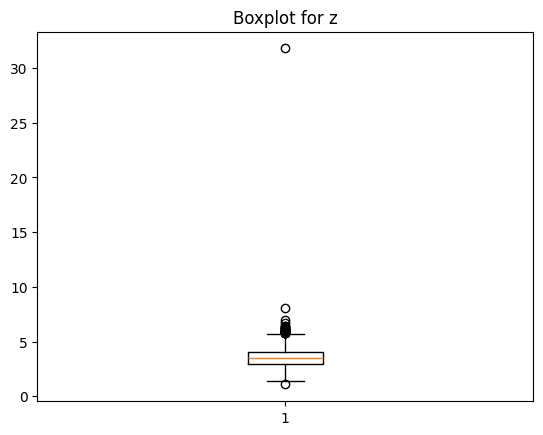

In [15]:
import matplotlib.pyplot as plt
cols = ['carat','price', 'x', 'y', 'z']

for col in cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

In [16]:
# IQR Method

In [17]:

cols = ['carat', 'price', 'x', 'y', 'z']

In [18]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)
    print(df.shape)

(53940, 10)
(53940, 10)
(53940, 10)
(53940, 10)
(53940, 10)


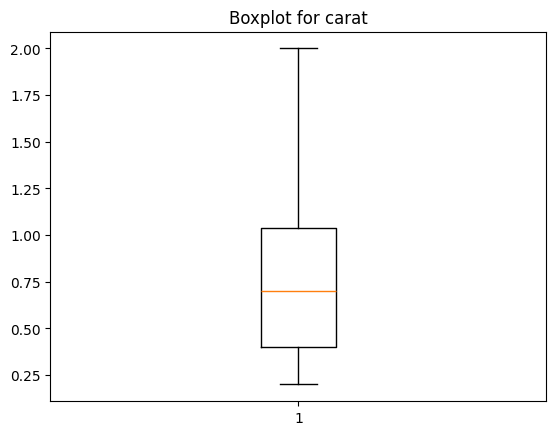

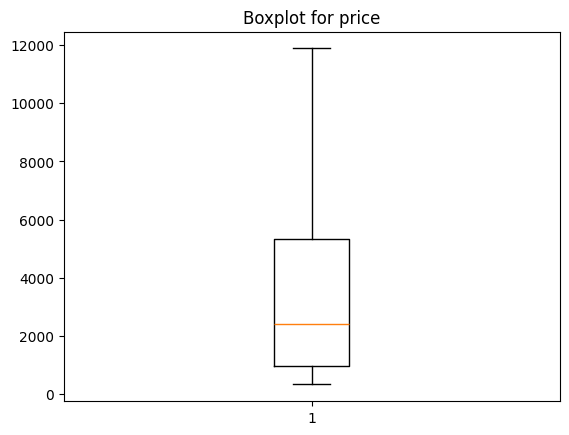

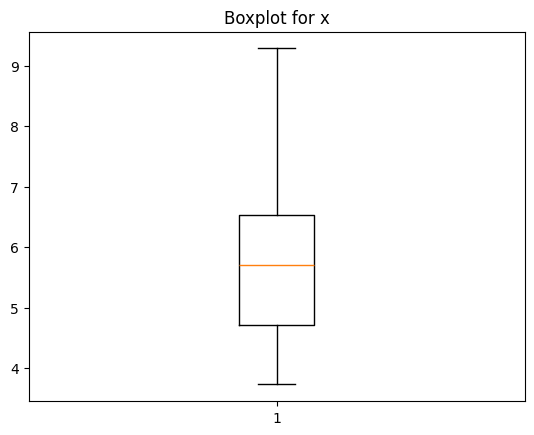

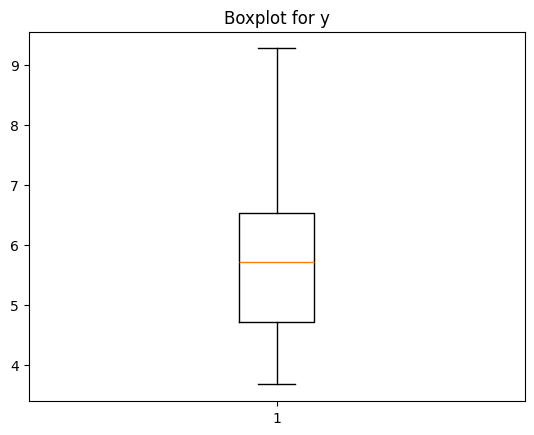

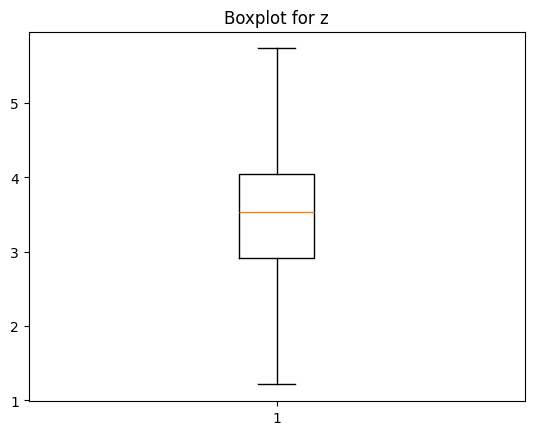

In [19]:
import matplotlib.pyplot as plt
cols = ['carat','price', 'x', 'y', 'z']

for col in cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

In [20]:
#skewness

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(df[num_cols].skew())

carat    0.899893
depth   -0.082294
table    0.796896
price    1.148304
x        0.394179
y        0.389861
z        0.387198
dtype: float64


In [22]:
import numpy as np
df['price'] = np.log1p(df['price'])
df['carat'] = np.log1p(df['carat'])

# **EDA**

In [23]:
# 1 Distribution plots for price, carat, x, y, z

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

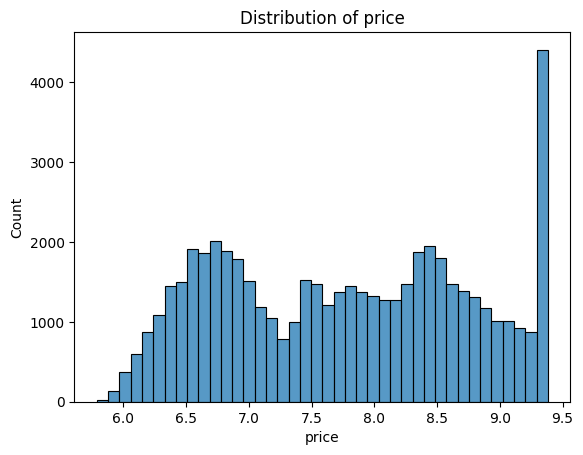

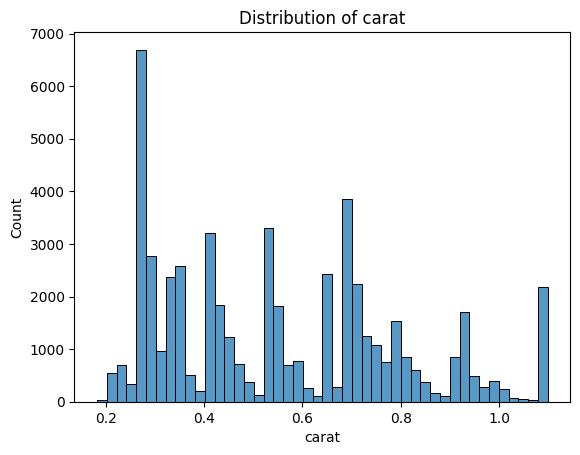

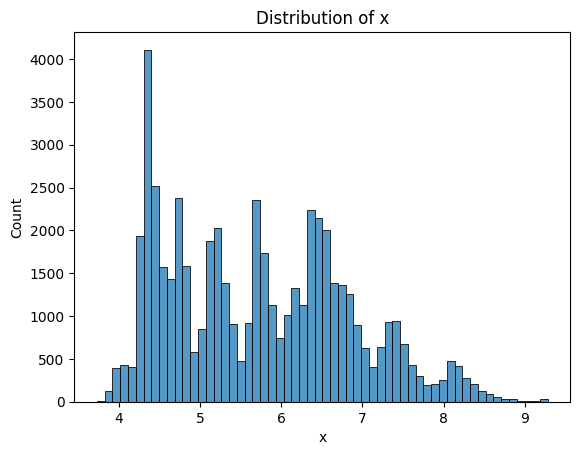

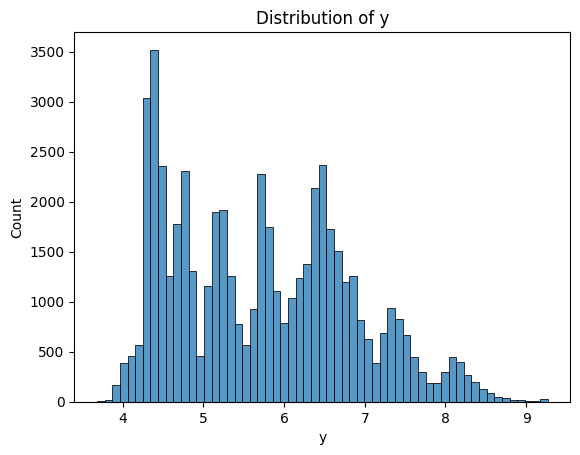

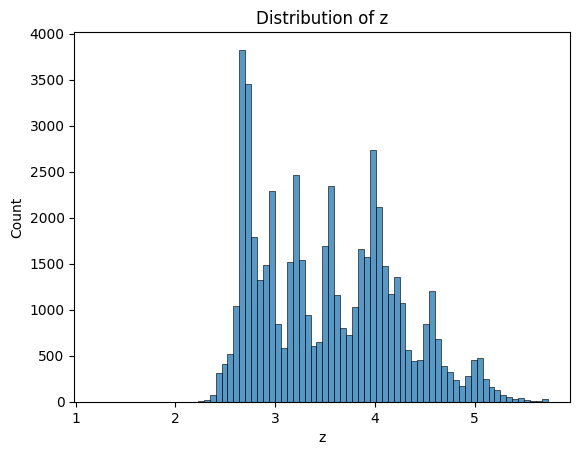

In [25]:
cols = ['price', 'carat', 'x', 'y', 'z']

for col in cols:
    plt.figure()
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [26]:
# 2 Count plots for categorical features (cut, color, clarity)

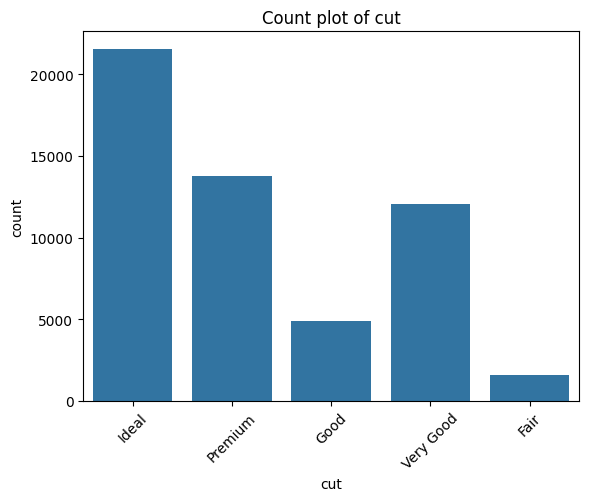

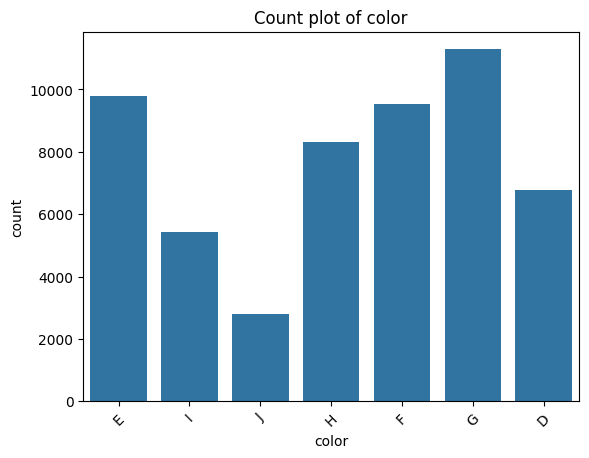

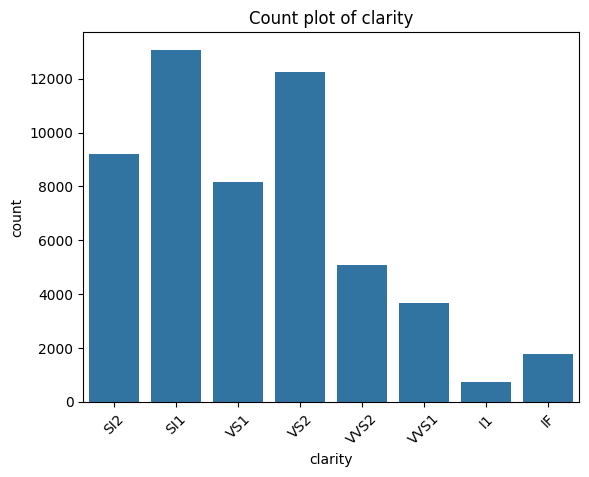

In [27]:
cat_cols = ['cut', 'color', 'clarity']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [28]:
# 3 Price variation with carat, cut, color, clarity using boxplots

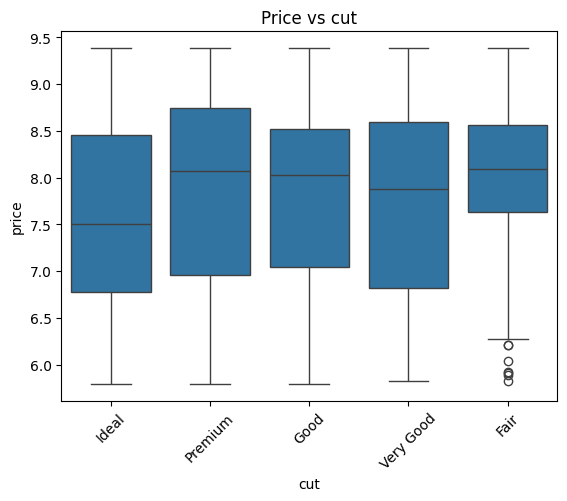

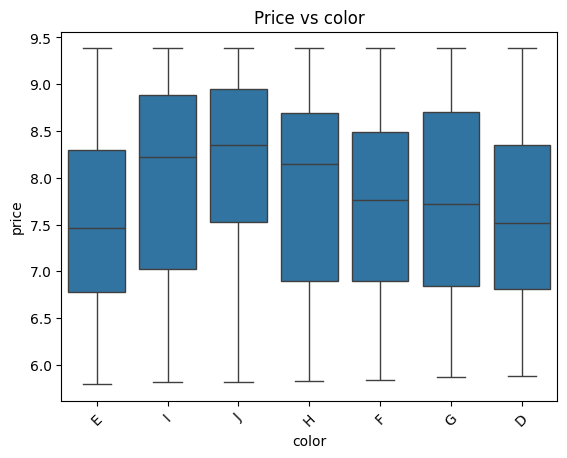

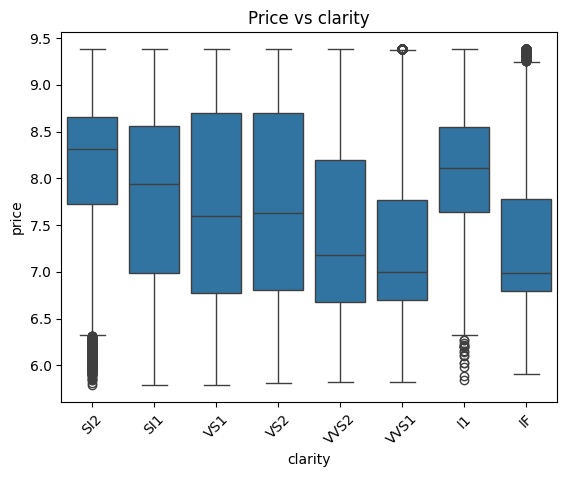

In [29]:
cat_cols = ['cut', 'color', 'clarity']

for col in cat_cols:
    plt.figure()
    sns.boxplot(x=df[col], y=df['price'])
    plt.title(f"Price vs {col}")
    plt.xticks(rotation=45)
    plt.show()

In [30]:
# 4 Correlation heatmap for numerical features


In [31]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

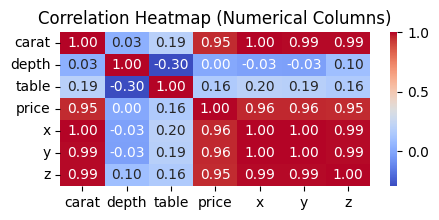

In [32]:
num_df = df.select_dtypes(include=['int64', 'float64'])

corr = num_df.corr()

plt.figure(figsize=(5,2))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Columns)")
plt.show()

In [33]:
# 5 Scatterplot matrix for carat, x, y, z, and price

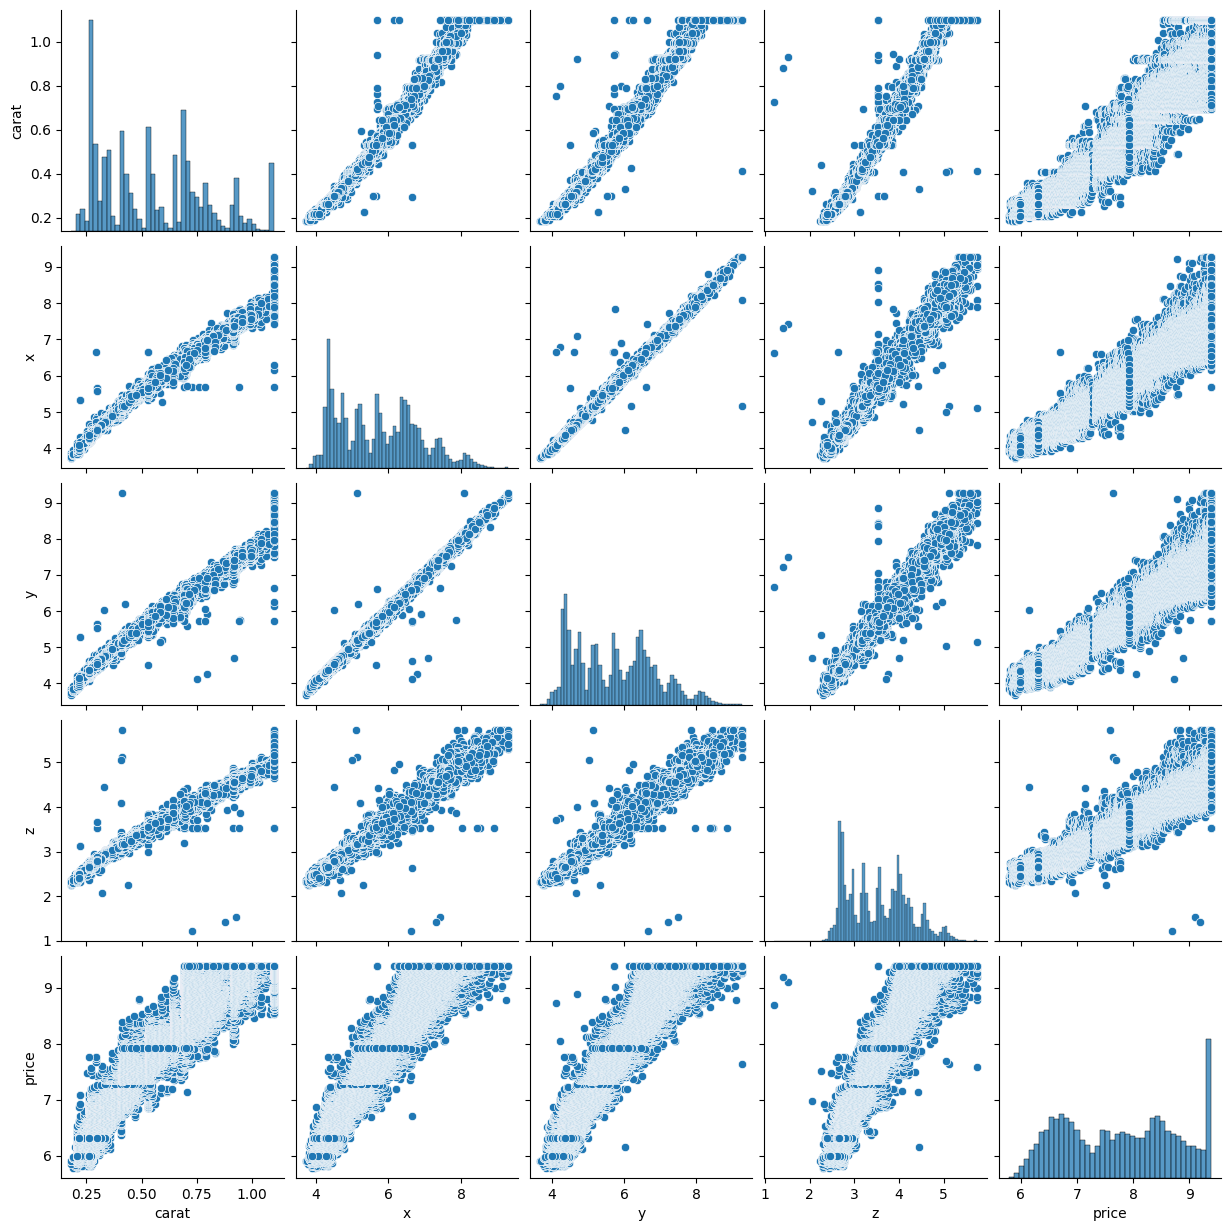

In [34]:
sns.pairplot(df[['carat', 'x', 'y', 'z', 'price']])
plt.show()

In [35]:
# 6 Carat vs. price regression lineplot

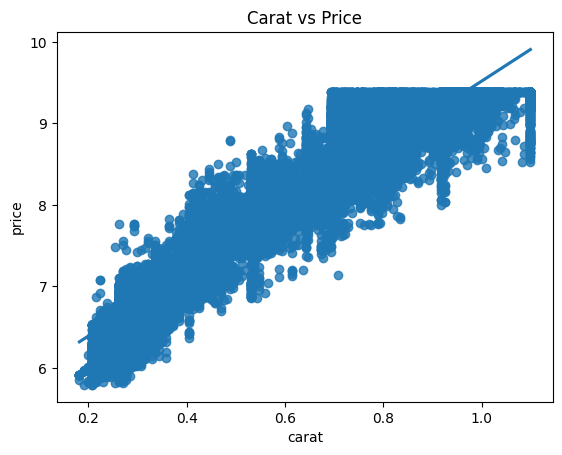

In [36]:
sns.regplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()

In [37]:
#7 Average price per cut, color, clarity categories using bar plots

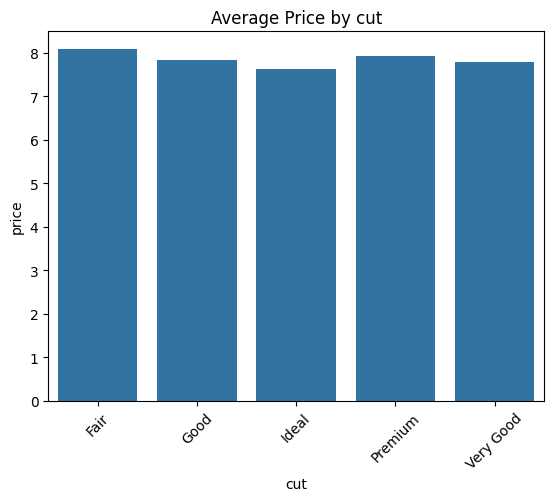

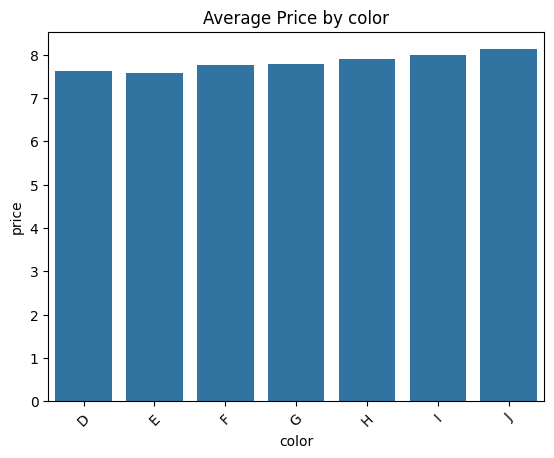

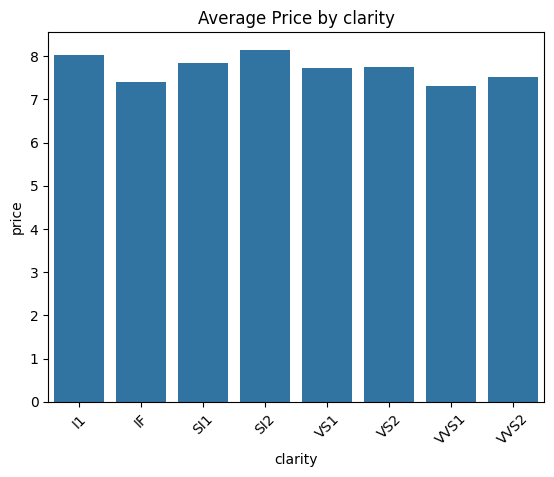

In [38]:
for col in ['cut', 'color', 'clarity']:
    avg_price = df.groupby(col)['price'].mean().reset_index()

    plt.figure()
    sns.barplot(x=col, y='price', data=avg_price)
    plt.title(f"Average Price by {col}")
    plt.xticks(rotation=45)
    plt.show()

# **Feature Engineering**

In [39]:
# convert INR

In [40]:
usd_to_inr = 83

df['price_inr'] = df['price'] * usd_to_inr

In [41]:
#volume

In [42]:
df['volume'] = df['x'] * df['y'] * df['z']

In [43]:
# price per carat

In [44]:
df['price_per_carat'] = df['price'] / df['carat']

In [45]:
# Dimension Ratio

In [46]:
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

In [47]:
#carat category

In [48]:
def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

In [49]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z', 'price_inr', 'volume', 'price_per_carat', 'dimension_ratio',
       'carat_category'],
      dtype='object')

In [50]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.207014,Ideal,E,SI2,61.5,55.0,5.789960,3.95,3.98,2.43,480.566694,38.202030,27.968908,1.631687,Light
1,0.190620,Premium,E,SI1,59.8,61.0,5.789960,3.89,3.84,2.31,480.566694,34.505856,30.374301,1.673160,Light
2,0.207014,Good,E,VS1,56.9,65.0,5.793014,4.05,4.07,2.31,480.820129,38.076885,27.983657,1.757576,Light
3,0.254642,Premium,I,VS2,62.4,58.0,5.814131,4.20,4.23,2.63,482.572834,46.724580,22.832547,1.602662,Light
4,0.270027,Good,J,SI2,63.3,58.0,5.817111,4.34,4.35,2.75,482.820226,51.917250,21.542691,1.580000,Light
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,Ideal,D,SI1,60.8,57.0,7.922261,5.75,5.76,3.50,657.547668,115.920000,14.607978,1.644286,Medium
53936,0.542324,Good,D,SI1,63.1,55.0,7.922261,5.69,5.75,3.61,657.547668,118.110175,14.607978,1.584488,Medium
53937,0.530628,Very Good,D,SI1,62.8,60.0,7.922261,5.66,5.68,3.56,657.547668,114.449728,14.929965,1.592697,Medium
53938,0.620576,Premium,H,SI2,61.0,58.0,7.922261,6.15,6.12,3.74,657.547668,140.766120,12.765970,1.640374,Medium


In [51]:
#encode

In [52]:
from sklearn.preprocessing import OrdinalEncoder
df["cut"] = OrdinalEncoder().fit_transform(df[["cut"]])
df["color"] = OrdinalEncoder().fit_transform(df[["color"]])
df["clarity"] = OrdinalEncoder().fit_transform(df[["clarity"]])
df["carat_category"] =OrdinalEncoder().fit_transform(df[["carat_category"]])

In [53]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.207014,2.0,1.0,3.0,61.5,55.0,5.789960,3.95,3.98,2.43,480.566694,38.202030,27.968908,1.631687,0.0
1,0.190620,3.0,1.0,2.0,59.8,61.0,5.789960,3.89,3.84,2.31,480.566694,34.505856,30.374301,1.673160,0.0
2,0.207014,1.0,1.0,4.0,56.9,65.0,5.793014,4.05,4.07,2.31,480.820129,38.076885,27.983657,1.757576,0.0
3,0.254642,3.0,5.0,5.0,62.4,58.0,5.814131,4.20,4.23,2.63,482.572834,46.724580,22.832547,1.602662,0.0
4,0.270027,1.0,6.0,3.0,63.3,58.0,5.817111,4.34,4.35,2.75,482.820226,51.917250,21.542691,1.580000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.542324,2.0,0.0,2.0,60.8,57.0,7.922261,5.75,5.76,3.50,657.547668,115.920000,14.607978,1.644286,1.0
53936,0.542324,1.0,0.0,2.0,63.1,55.0,7.922261,5.69,5.75,3.61,657.547668,118.110175,14.607978,1.584488,1.0
53937,0.530628,4.0,0.0,2.0,62.8,60.0,7.922261,5.66,5.68,3.56,657.547668,114.449728,14.929965,1.592697,1.0
53938,0.620576,3.0,4.0,3.0,61.0,58.0,7.922261,6.15,6.12,3.74,657.547668,140.766120,12.765970,1.640374,1.0


In [54]:
# Feature Selection RandomForest

In [57]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

x = df.drop(["price","price_inr"], axis=1)
y = df['price']

model = RandomForestRegressor(random_state=42)
model.fit(x, y)

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
7                 y    0.700450
9            volume    0.207227
0             carat    0.032599
3           clarity    0.019461
10  price_per_carat    0.019208
6                 x    0.012738
2             color    0.007142
8                 z    0.000450
11  dimension_ratio    0.000225
5             table    0.000175
1               cut    0.000152
4             depth    0.000140
12   carat_category    0.000033


In [58]:
# droping the column

In [59]:
x  = x .drop("carat_category", axis=1)

# **Model Buillding**

In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)


In [61]:
x_train

,carat,cut,color,clarity,depth,table,x,y,z,volume,price_per_carat,dimension_ratio
20971,0.928219,4.0,5.0,2.0,63.0,58.0,7.24,7.32,4.59,243.255312,9.830886,1.586057
28025,0.262364,2.0,1.0,5.0,62.4,57.0,4.29,4.33,2.69,49.968633,24.739358,1.602230
29803,0.262364,4.0,0.0,2.0,63.1,55.0,4.31,4.28,2.71,49.990828,25.023473,1.584871
44003,0.262364,1.0,5.0,2.0,63.8,57.0,4.19,4.27,2.70,48.306510,22.788491,1.566667
49974,0.254642,4.0,3.0,7.0,60.9,57.0,4.28,4.32,2.61,48.257856,24.722004,1.647510
...,...,...,...,...,...,...,...,...,...,...,...,...
44675,0.438255,2.0,1.0,2.0,61.8,58.0,5.24,5.28,3.25,89.918400,16.848617,1.618462
24158,0.920283,3.0,1.0,2.0,60.3,58.0,7.47,7.43,4.49,249.204429,10.195963,1.659243
848,0.542324,2.0,4.0,7.0,60.9,57.0,5.79,5.77,3.52,117.597216,14.681377,1.642045
41472,0.343590,2.0,0.0,4.0,62.9,57.0,4.75,4.73,2.98,66.953150,20.709532,1.590604


In [62]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((43152, 12), (43152,), (10788, 12), (10788,))

In [63]:
y

,price
0,5.789960
1,5.789960
2,5.793014
3,5.814131
4,5.817111
...,...
53935,7.922261
53936,7.922261
53937,7.922261
53938,7.922261


In [ ]:
# 1 linear Regressor

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))
print("R_Squared:",r2_score(y_test,y_pred))

MAE: 0.10985276586179453
MSE: 0.02227939905840212
RMSE: 0.14926285223859995
R_Squared: 0.9771564051535276


In [65]:
# 2 RandomforestRegressor

In [66]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor ()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))
print("R_Squared:",r2_score(y_test,y_pred))

MAE: 0.017744746600594847
MSE: 0.0014026177880276075
RMSE: 0.03745153919437234
R_Squared: 0.9985618628047297


In [67]:
# 3 XGBoost Regressor

In [68]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))
print("R_Squared:",r2_score(y_test,y_pred))


MAE: 0.031436985480257564
MSE: 0.0020404630382591486
RMSE: 0.0451714847913941
R_Squared: 0.9979078649822193


In [69]:
# 4 Decision Tree Regressor

In [70]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))
print("R_Squared:",r2_score(y_test,y_pred))


MAE: 0.023947806023474103
MSE: 0.0032768183009617207
RMSE: 0.05724350007609354
R_Squared: 0.9966402006869011


In [71]:
#5 kNN Regressor

In [72]:
from sklearn.neighbors import KNeighborsRegressor
model =KNeighborsRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))
print("R_Squared:",r2_score(y_test,y_pred))


MAE: 0.08912620802503972
MSE: 0.01665693517644984
RMSE: 0.12906174947074692
R_Squared: 0.982921250364189


In [73]:
#6 ANN Regressor

In [74]:
from sklearn.model_selection import train_test_split

x= df.drop(["price","price_inr"], axis=1)
y =df['price']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [75]:
from sklearn.neural_network import MLPRegressor
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=200,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test, y_pred))
print("R_Squared:",r2_score(y_test,y_pred))

MAE: 0.10317793834177698
MSE: 0.018907405337073423
RMSE: 0.1375042011615406
R_Squared: 0.9803792624581809


In [76]:
# saving the best model

In [77]:
import pickle

In [78]:
with open('random_forest_Regressor_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# **Clustering**

In [79]:
x = df.drop(['price', 'price_inr'],axis=1)

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [81]:
# elbow method

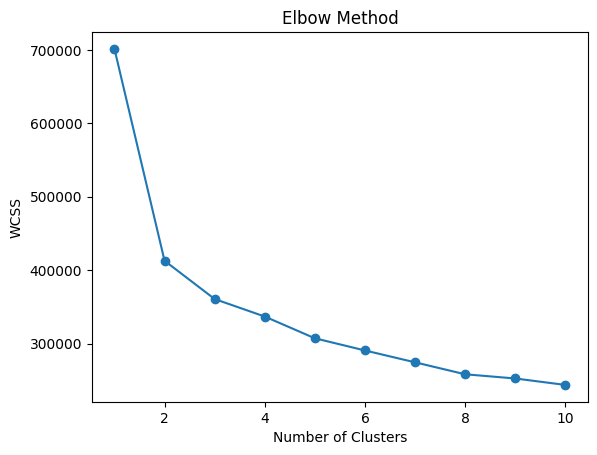

In [82]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [83]:
#apply k-means

In [84]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(x_scaled)

In [85]:
#Analyze Clusters

In [86]:
cluster_summary = df.groupby('cluster')[['price', 'carat','cut']].mean()
print(cluster_summary)

            price     carat       cut
cluster                              
0        8.326487  0.654531  2.548226
1        6.858478  0.335080  2.529266
2        9.120808  0.950961  2.633778


In [87]:
#Name Clusters

In [88]:
def name_cluster(row):
    if row['price'] > 10000:
        return "Premium Diamonds"
    elif row['price'] > 4000:
        return "Mid-range Diamonds"
    else:
        return "Affordable Diamonds"

cluster_summary['name'] = cluster_summary.apply(name_cluster, axis=1)

print(cluster_summary)

            price     carat       cut                 name
cluster                                                   
0        8.326487  0.654531  2.548226  Affordable Diamonds
1        6.858478  0.335080  2.529266  Affordable Diamonds
2        9.120808  0.950961  2.633778  Affordable Diamonds


In [89]:
x_train.shape ,y_train.shape,x_test.shape,y_test.shape

((43152, 12), (43152,), (10788, 12), (10788,))

In [90]:
# PCA

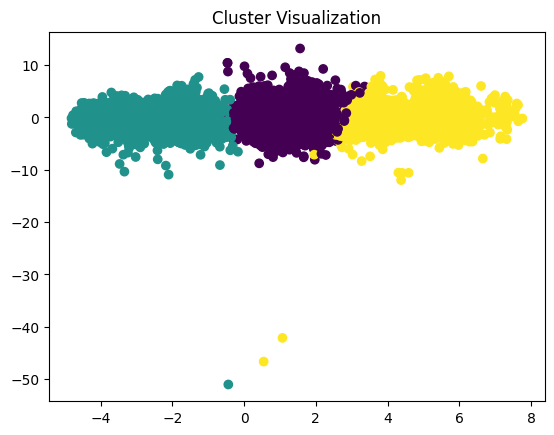

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

plt.scatter(x_pca[:,0], x_pca[:,1], c=df['cluster'])
plt.title("Cluster Visualization")
plt.show()

In [92]:
#Save the model K-Means

In [93]:
import pickle

with open("kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

# **StreamLit**

In [94]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 64.5 MB/s eta 0:00:00
--2026-04-24 13:12:51--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-24 13:12:52--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-24T13%3A53%3A11Z&rscd=attachment%3B+filename%3Dcl

In [95]:
!pip install streamlit-option-menu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 20.8 MB/s eta 0:00:00


In [96]:
%%writefile Diamond.py
import streamlit as st
import numpy as np
import pickle


price_model = pickle.load(open("random_forest_Regressor_model.pkl", "rb"))
cluster_model = pickle.load(open("kmeans_model.pkl", "rb"))



st.header("💎 Diamond Price Prediction")


st.sidebar.title("💎 Navigation")
page = st.sidebar.radio("Select Page", ["Price Prediction", "Cluster Prediction"])

# input function
def get_input():
    st.subheader("Enter Diamond Details")


# ORIGINAL FEATURES
    carat = st.number_input("Carat", 0.0, 10.0, 0.5)
    x = st.number_input("Length (x)", 0.0, 20.0, 5.0)
    y = st.number_input("Width (y)", 0.0, 20.0, 5.0)
    z = st.number_input("Depth (z)", 0.0, 20.0, 3.0)

    cut = st.selectbox("Cut (Encoded)", [0,1,2,3,4])
    color = st.selectbox("Color (Encoded)", [0,1,2,3,4,5,6])
    clarity = st.selectbox("Clarity (Encoded)", [0,1,2,3,4,5,6,7])

    #  NEW FEATURES
    volume = st.number_input("Volume", 0.0, 1000.0, 50.0)
    price_per_carat = st.number_input("Price per Carat", 0.0, 10000.0, 100.0)
    dimension_ratio = st.number_input("Dimension Ratio", 0.0, 10.0, 1.5)
    carat_category = st.selectbox("Carat Category", [0,1,2])
    depth = st.number_input("Depth", 0.0, 100.0, 60.0)
    table = st.number_input("Table", 0.0, 100.0, 55.0)

    #  FEATURE ARRAY
    features = np.array([[
        carat, x, y, z,
        cut, color, clarity,
        volume, price_per_carat,
        dimension_ratio, carat_category,
        depth, table
    ]])

    return features

# PRICE PAGE
if page == "Price Prediction":
    st.title("💰 Price Prediction")

    features = get_input()

    if st.button("Predict Price"):
        pred = price_model.predict(features)
        st.success(f"Predicted Price: ₹ {round(pred[0],2)}")

# CLUSTER PAGE
elif page == "Cluster Prediction":
    st.title("📊 Cluster Prediction")

    features = get_input()

    if st.button("Predict Cluster"):
        cluster = cluster_model.predict(features)

        cluster_map = {
            0: "Affordable Diamonds",
            1: "Mid-range Diamonds",
            2: "Premium Diamonds"
        }

        st.success(f"Cluster: {cluster[0]} - {cluster_map.get(cluster[0])}")

Writing Diamond.py


In [97]:
!streamlit run /content/Diamond.py &>/content/logs.txt &

In [98]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://cash-trance-corresponding-utilization.trycloudflare.com


In [ ]:
df